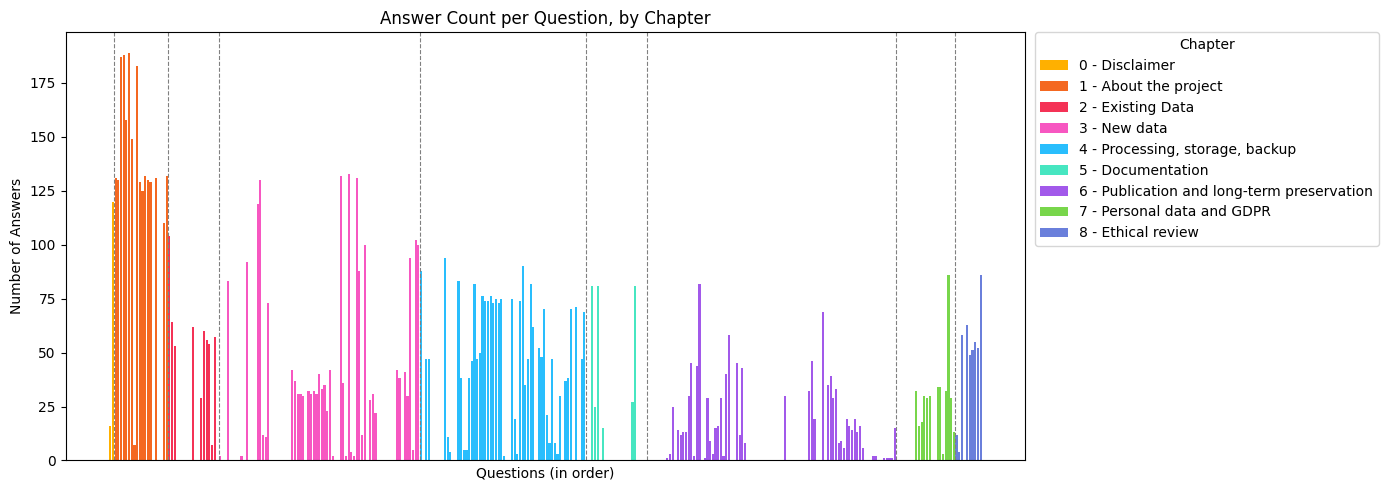

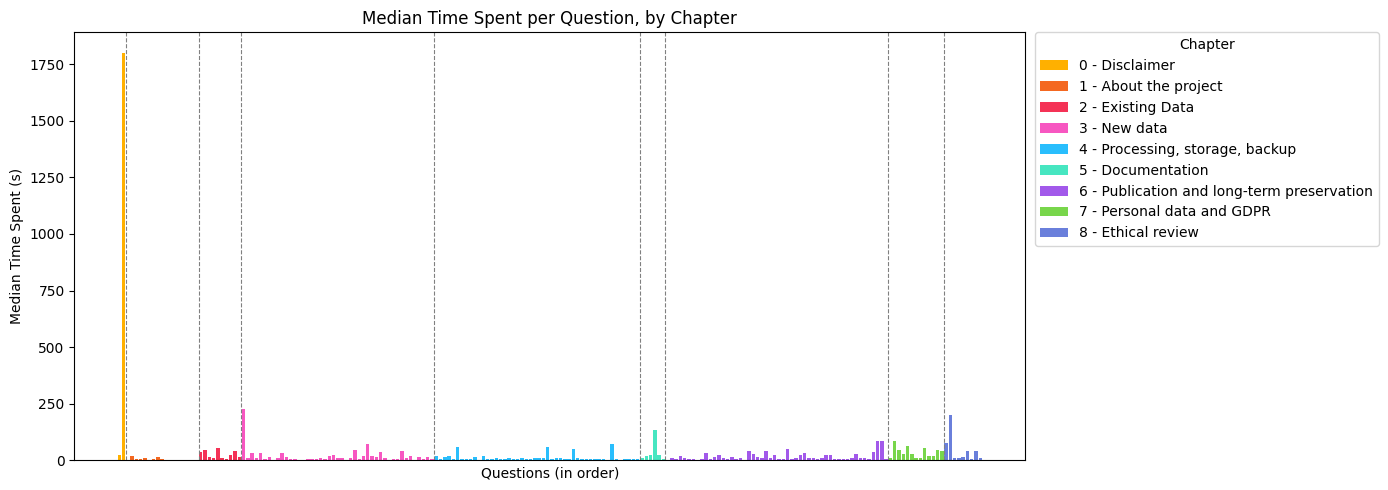

124 questions with zero answers:

                                        chapter                                                                                                                                     title                 type  depth                                                                                                                          km_ids
0                         1 - About the project                                                                                                                           Project acronym        ValueQuestion      1  [chalmers:root:3.0.1, chalmers:root:3.0.0, chalmers:root:3.0.2, chalmers:root:3.0.3, chalmers:root:3.0.5, chalmers:root:3.0.4]
1                         1 - About the project                                                                                         What specific hard/software do you need, and why?        ValueQuestion      1  [chalmers:root:3.0.1, chalmers:root:3.0.0, chalmers:root:3.0.2, cha

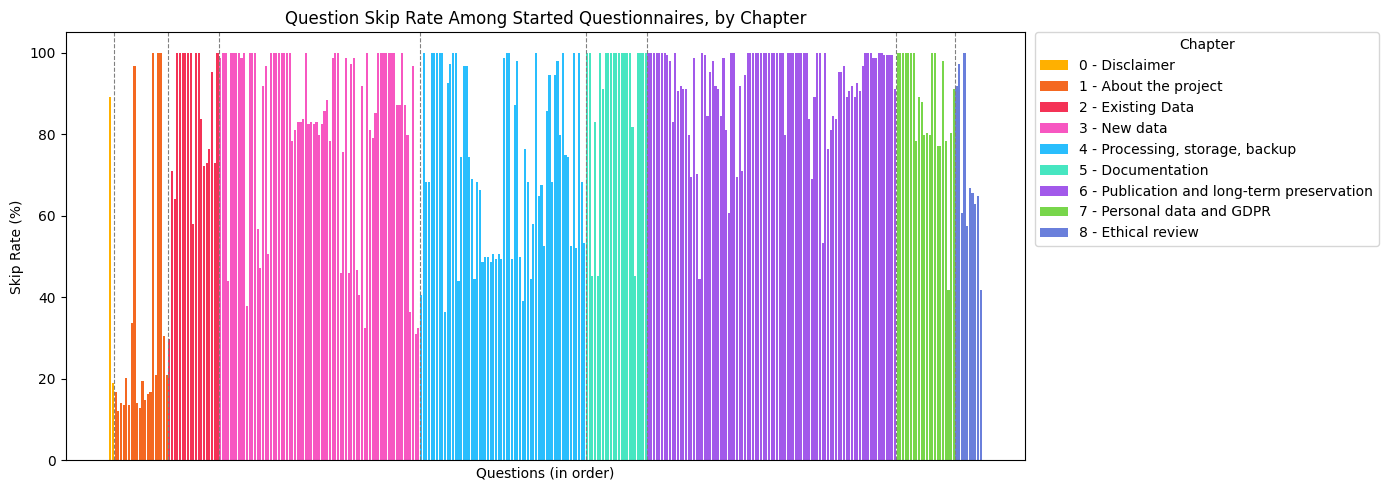

In [20]:
# Running basic stats:
# 1. Bar plot for edited vs unedited autodmps----------------------------------------------------------------------------------------------------OK
# 2. Bar plot autocreated vs user-created dmps --------------------------------------------------------------------------------------------------OK
# 3. % users who have  edited autodmps ----------------------------------------------------------------------------------------------------------OK

# Questions to be answered are the following: 
# 1. Plot all questions by  chapter with at least one answer by a user, x = question, y= t(s)
# 2. plot questions vs number of answers --------------------------------------------------------------------------------------------------------OK
# 3. plot missing answers
# 4. same as above, but y = % questions skipped - base on questions which were started but not answered... measures strategy: skip questions ----OK
# 5. questions with broad distribution of times
# 6. antal planer där det tar längre än 20 minuter (strategi: fokus/tänka på det)# ── Auto-generation detection ─────────────────────────────────────────────────

# All question_uuids that auto-gen populates (extracted from the listed paths)
AUTO_QUESTION_UUIDS = {
    # Contributors list + sub-questions
    '73d686bd-7939-412e-8631-502ee6d9ea7b',  # Contributors
    '6155ad47-3d1e-4488-9f2a-742de1e56580',  # name
    '3a2ffc13-6a0e-4976-bb34-14ab6d938348',  # email
    '6295a55d-48d7-4f3c-961a-45b38eeea41f',  # orcid
    '68530470-1f1c-4448-8593-63a288713a66',  # affiliation
    '829dcda6-db8a-40ac-819a-92b9b52490f5',  # role
    # Research Projects list + sub-questions
    'c3dabaaf-c946-4a0d-889c-ede966f97667',  # Research Project(s)
    'f0ef08fd-d733-465c-bc66-5de0b826c41b',  # project name
    '22583d74-3c98-4e0a-b363-26d767c88212',  # description
    'de84b9b5-bcd0-4954-8370-72ea83916b8c',  # start date
    'cabc6f07-6015-454e-b97a-c34db4ec0c60',  # end date
    '36a87eac-402d-43fb-a0df-ac5963bdf87d',  # funding (list)
    '0b12fb8c-ee0f-40c0-9c53-b6826b786a0c',  # funder
    '54ff3b18-652f-4235-8f9f-3c87e2d63169',  # status
    '1ccbd0bb-4263-4240-9dc5-936ef09eef53',  # grant id
}

# Default answer values written by auto-gen — used as the auto-gen signature
AUTO_SIGNATURES = {
    '68530470-1f1c-4448-8593-63a288713a66': 'd8efc3fb-9717-4566-9529-e89e71b1554d',  # aff = CTH
    '829dcda6-db8a-40ac-819a-92b9b52490f5': 'f7468e79-c621-4ac9-95e0-263ebdf23c73',  # role = Contact
}


def classify_projects(answers_df):
    """
    Classify each questionnaire (project) as:
      - 'auto_untouched' : auto-generated, only auto-set questions answered
      - 'auto_edited'    : auto-generated, additional answers outside auto-set
      - 'non_auto'       : not auto-generated
    A project is 'auto-generated' iff it contains *all* AUTO_SIGNATURES.
    """
    # Questionnaires matching every signature
    sig_sets = [
        set(answers_df.loc[
            (answers_df['question_uuid'] == q) & (answers_df['reply_value'] == v),
            'questionnaire_uuid'
        ].unique())
        for q, v in AUTO_SIGNATURES.items()
    ]
    auto_qids = set.intersection(*sig_sets) if sig_sets else set()

    answered_per_q = answers_df.groupby('questionnaire_uuid')['question_uuid'].agg(set)

    rows = []
    for qid, answered in answered_per_q.items():
        if qid in auto_qids:
            category = 'auto_edited' if (answered - AUTO_QUESTION_UUIDS) else 'auto_untouched'
        else:
            category = 'non_auto'
        rows.append((qid, category))

    return pd.DataFrame(rows, columns=['questionnaire_uuid', 'category'])


# ── Plot ──────────────────────────────────────────────────────────────────────

def plot_project_categories(classification_df):
    counts = classification_df['category'].value_counts().reindex(
        ['non_auto', 'auto_untouched', 'auto_edited'], fill_value=0
    )

    labels = ['Non auto-generated', 'Auto-generated\n(untouched)', 'Auto-generated\n(edited)']
    colors = ['#29BEFD', '#FFB000', '#F46821']

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, counts.values, color=colors)

    for bar, n in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{n}', ha='center', va='bottom', fontsize=11)

    ax.set_title('Projects by Auto-generation Status')
    ax.set_ylabel('Number of projects')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('project_categories.png', dpi=150)
    plt.show()


# ── Main addition ─────────────────────────────────────────────────────────────

if __name__ == '__main__':
    answers_df, projects_df, km_df = load_pickles('2026-04-23')

    classification_df = classify_projects(answers_df)
    print(classification_df['category'].value_counts())

    plot_project_categories(classification_df)

# Some preprocessing:
# 1. sållar bort test + allt som bara skapats av Data Office
# 2. compare questions between KMs and identify same question and list their different uuids: [q_text, [quuid, KMID]]

import pandas as pd
import matplotlib.pyplot as plt

# ── Constants ────────────────────────────────────────────────────────────────

CHAPTER_LABELS = {
    'ca48f269-5a4e-42fb-a4e8-6f2dc9458e65': '0 - Disclaimer',
    '1e85da40-bbfc-4180-903e-6c569ed2da38': '1 - About the project',
    '82fd0cce-2b41-423f-92ad-636d0872045c': '2 - Existing Data',
    'b1df3c74-0b1f-4574-81c4-4cc2d780c1af': '3 - New data',
    '10a10ffd-bfe1-4c6b-bbb6-3dfb1e63a5d5': '4 - Processing, storage, backup',
    'c7194506-2a18-4436-8590-9bf584833172': '5 - Documentation',
    'd5b27482-b598-4b8c-b534-417d4ad27394': '6 - Publication and long-term preservation',
    '8eb418fe-f415-44cd-8027-5fac5fc025c1': '7 - Personal data and GDPR',
    '6fd759d2-917f-4489-bacd-2700a305cbed': '8 - Ethical review',
    '5897e561-05ce-4a38-a71b-12e4e96ebaec': '9 - Support',
}

CHAPTER_COLORS = [
    '#FFB000', '#F46821', '#F43256', '#F757C1', '#29BEFD',
    '#47E6C1', '#A259EA', '#78D64B', '#6A7FDB', '#777777',
]

# ── I/O ──────────────────────────────────────────────────────────────────────

def load_pickles(date):
    return tuple(pd.read_pickle(f'{name}_{date}') for name in ('answers_df', 'projects_df', 'km_df'))

# ── Cleaning ─────────────────────────────────────────────────────────────────

def clean_projects(df):
    return df[~df['name'].str.contains('test|draft', case=False, na=False)].reset_index(drop=True)

# ── Analysis ─────────────────────────────────────────────────────────────────

def build_analysis_df(km_df, answers_df):
    km_df = km_df.copy()
    km_df['chapter'] = km_df['path'].str.split('.').str[0].map(CHAPTER_LABELS)

    unique_q = (
        km_df.sort_values('path')
        .drop_duplicates(subset='question_uuid')
        [['question_uuid', 'path', 'title', 'type', 'chapter']]
    )
    unique_q['depth'] = (unique_q['path'].str.count(r'\.') - 1).clip(lower=0) // 2

    km_presence   = km_df.groupby('question_uuid')['km_id'].agg(list).reset_index(name='km_ids')
    answer_counts = answers_df.groupby('question_uuid').size().reset_index(name='answer_count')

    return (
        unique_q
        .merge(km_presence,   on='question_uuid', how='left')
        .merge(answer_counts, on='question_uuid', how='left')
        .assign(answer_count=lambda df: df['answer_count'].fillna(0).astype(int))
        .sort_values('chapter')
        .reset_index(drop=True)
    )


def compute_time_per_question(answers_df):
    """
    Estimate median time spent per question (seconds) using the gap between
    consecutive reply_timestamps within the same questionnaire.
    Gaps > 30 min are capped to exclude session breaks.
    """
    df = answers_df.copy()
    df['reply_timestamp'] = pd.to_datetime(df['reply_timestamp'])
    df = df.sort_values(['questionnaire_uuid', 'reply_timestamp'])

    df['time_diff_s'] = (
        df.groupby('questionnaire_uuid')['reply_timestamp']
        .diff()
        .dt.total_seconds()
        .clip(upper=1800)   # cap at 30 min
    )
    return (
        df.groupby('question_uuid')['time_diff_s']
        .median()
        .reset_index(name='median_time_s')
    )


def compute_skip_rate(analysis_df, answers_df):
    """
    % of started questionnaires that skipped each question.
    Started = questionnaire has at least one answer.
    Skipped = started questionnaire never answered that question.
    """
    n_started = answers_df['questionnaire_uuid'].nunique()

    answered_per_q = (
        answers_df.groupby('question_uuid')['questionnaire_uuid']
        .nunique()
        .reset_index(name='n_answered')
    )
    df = analysis_df.merge(answered_per_q, on='question_uuid', how='left')
    df['n_answered']  = df['n_answered'].fillna(0).astype(int)
    df['skip_rate']   = (1 - df['n_answered'] / n_started) * 100
    return df


# ── Shared plot helper ────────────────────────────────────────────────────────

def _chapter_bar_plot(df, y_col, ylabel, title, filename):
    chapters  = sorted(df['chapter'].dropna().unique())
    color_map = {ch: CHAPTER_COLORS[i % len(CHAPTER_COLORS)] for i, ch in enumerate(chapters)}

    fig, ax = plt.subplots(figsize=(14, 5))
    for chapter in chapters:
        sub = df[df['chapter'] == chapter]
        ax.bar(sub.index, sub[y_col], color=color_map[chapter], label=chapter)

    for x in df.groupby('chapter', sort=False).apply(lambda g: g.index[-1], include_groups=False).values[:-1]:
        ax.axvline(x=x + 0.5, color='grey', linewidth=0.8, linestyle='--')

    ax.set_title(title)
    ax.set_xlabel('Questions (in order)')
    ax.set_ylabel(ylabel)
    ax.set_xticks([])
    ax.legend(title='Chapter', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()


# ── Plots ────────────────────────────────────────────────────────────────────

def plot_answer_counts(df):
    """Answer count per question, all questions."""
    _chapter_bar_plot(df, 'answer_count', 'Number of Answers',
                      'Answer Count per Question, by Chapter',
                      'answer_count_by_chapter.png')


def plot_time_per_question(analysis_df, answers_df):
    """Q1: Questions with ≥1 answer, y = median time spent (seconds)."""
    time_df = compute_time_per_question(answers_df)
    df = (
        analysis_df
        .merge(time_df, on='question_uuid', how='left')
        .dropna(subset=['median_time_s'])        # keep only answered questions
        .reset_index(drop=True)
    )
    _chapter_bar_plot(df, 'median_time_s', 'Median Time Spent (s)',
                      'Median Time Spent per Question, by Chapter',
                      'time_per_question.png')


def list_zero_answer_questions(analysis_df):
    """Q3: Questions with zero answers."""
    zero = (
        analysis_df[analysis_df['answer_count'] == 0]
        [['chapter', 'title', 'type', 'depth', 'km_ids']]
        .reset_index(drop=True)
    )
    print(f"{len(zero)} questions with zero answers:\n")
    print(zero.to_string())
    return zero


def plot_skip_rate(analysis_df, answers_df):
    """Q4: % of started questionnaires that skipped each question."""
    df = compute_skip_rate(analysis_df, answers_df).reset_index(drop=True)
    _chapter_bar_plot(df, 'skip_rate', 'Skip Rate (%)',
                      'Question Skip Rate Among Started Questionnaires, by Chapter',
                      'skip_rate_by_chapter.png')


# ── Main ─────────────────────────────────────────────────────────────────────

if __name__ == '__main__':
    answers_df, projects_df, km_df = load_pickles('2026-04-23')

    clean_projects_df = clean_projects(projects_df)
    analysis_df       = build_analysis_df(km_df, answers_df)

    plot_answer_counts(analysis_df)
    plot_time_per_question(analysis_df, answers_df)
    zero_df = list_zero_answer_questions(analysis_df)
    plot_skip_rate(analysis_df, answers_df)

In [21]:
time_df = compute_time_per_question(answers_df)
analysis_df_with_time = analysis_df.merge(time_df, on='question_uuid', how='left')

top = (
    analysis_df_with_time
    .nlargest(5, 'median_time_s')
    [['chapter', 'title', 'median_time_s', 'question_uuid']]
)
print(top.to_string())

                        chapter                                                                                                            title  median_time_s                         question_uuid
1                0 - Disclaimer    Do you allow other (Chalmers approved) services to read some of the information in this data management plan?    1800.000000  3c1c118c-7dfb-4d53-bc7d-47d44cede95e
41                 3 - New data                                                                                         Number of files/subjects     224.967555  448403e9-578b-4155-9017-d4aa9119ea6a
317          8 - Ethical review                                                                                                  Please describe     201.495236  25077b87-74da-4049-a6ad-e332b69da69f
184           5 - Documentation                                                                                                             Name     133.116574  2c9a222f-15bb-48b6-a589-83a8c2b5f7b3
302  7 - P

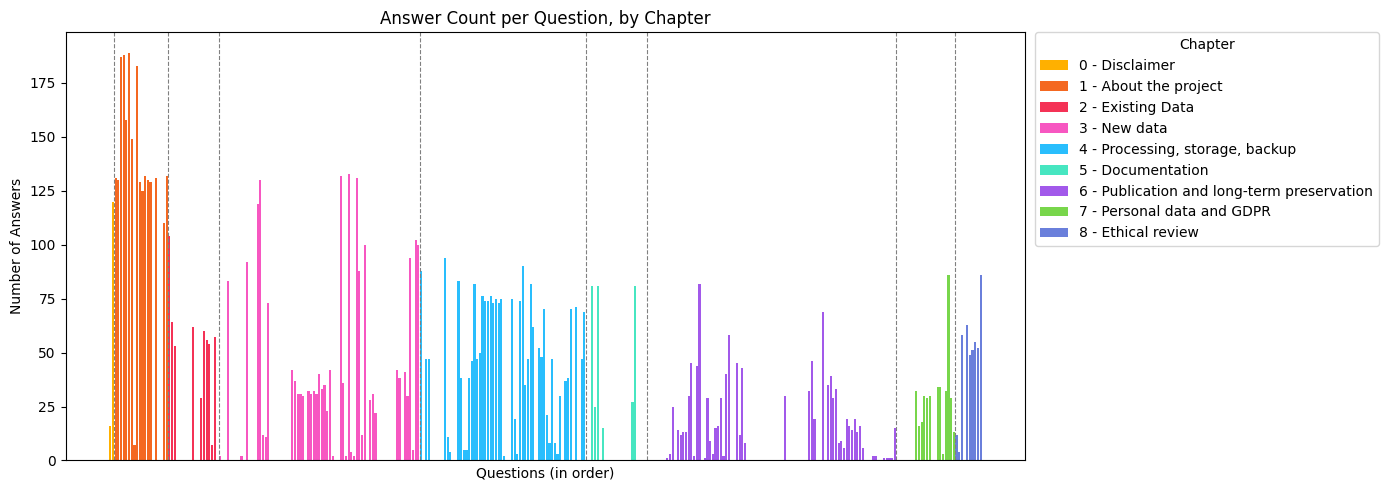

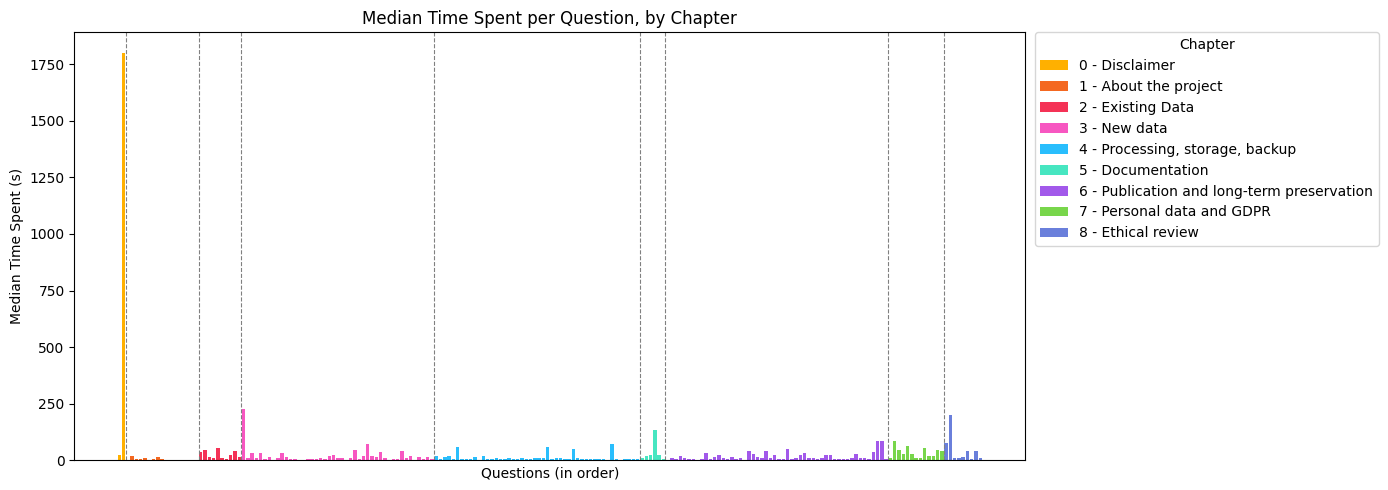

124 questions with zero answers:

                                        chapter                                                                                                                                     title                 type  depth                                                                                                                          km_ids
0                         1 - About the project                                                                                                                           Project acronym        ValueQuestion      1  [chalmers:root:3.0.1, chalmers:root:3.0.0, chalmers:root:3.0.2, chalmers:root:3.0.3, chalmers:root:3.0.5, chalmers:root:3.0.4]
1                         1 - About the project                                                                                         What specific hard/software do you need, and why?        ValueQuestion      1  [chalmers:root:3.0.1, chalmers:root:3.0.0, chalmers:root:3.0.2, cha

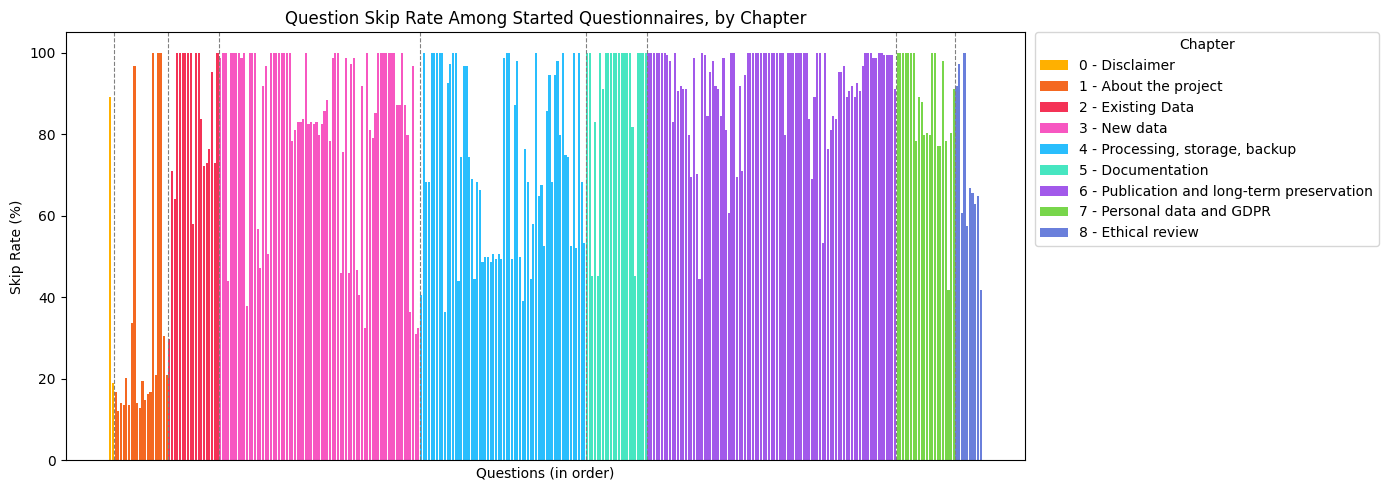

category
auto_edited       93
non_auto          37
auto_untouched    18
Name: count, dtype: int64


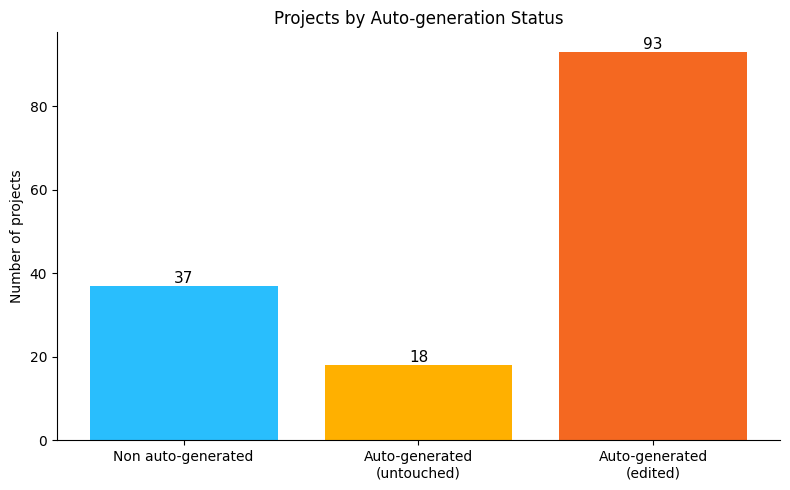

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Constants ────────────────────────────────────────────────────────────────

CHAPTER_LABELS = {
    'ca48f269-5a4e-42fb-a4e8-6f2dc9458e65': '0 - Disclaimer',
    '1e85da40-bbfc-4180-903e-6c569ed2da38': '1 - About the project',
    '82fd0cce-2b41-423f-92ad-636d0872045c': '2 - Existing Data',
    'b1df3c74-0b1f-4574-81c4-4cc2d780c1af': '3 - New data',
    '10a10ffd-bfe1-4c6b-bbb6-3dfb1e63a5d5': '4 - Processing, storage, backup',
    'c7194506-2a18-4436-8590-9bf584833172': '5 - Documentation',
    'd5b27482-b598-4b8c-b534-417d4ad27394': '6 - Publication and long-term preservation',
    '8eb418fe-f415-44cd-8027-5fac5fc025c1': '7 - Personal data and GDPR',
    '6fd759d2-917f-4489-bacd-2700a305cbed': '8 - Ethical review',
    '5897e561-05ce-4a38-a71b-12e4e96ebaec': '9 - Support',
}

CHAPTER_COLORS = [
    '#FFB000', '#F46821', '#F43256', '#F757C1', '#29BEFD',
    '#47E6C1', '#A259EA', '#78D64B', '#6A7FDB', '#777777',
]

# Question UUIDs populated by auto-generation
AUTO_QUESTION_UUIDS = {
    # Contributors list + sub-questions
    '73d686bd-7939-412e-8631-502ee6d9ea7b',  # Contributors
    '6155ad47-3d1e-4488-9f2a-742de1e56580',  # name
    '3a2ffc13-6a0e-4976-bb34-14ab6d938348',  # email
    '6295a55d-48d7-4f3c-961a-45b38eeea41f',  # orcid
    '68530470-1f1c-4448-8593-63a288713a66',  # affiliation
    '829dcda6-db8a-40ac-819a-92b9b52490f5',  # role
    # Research Projects list + sub-questions
    'c3dabaaf-c946-4a0d-889c-ede966f97667',  # Research Project(s)
    'f0ef08fd-d733-465c-bc66-5de0b826c41b',  # project name
    '22583d74-3c98-4e0a-b363-26d767c88212',  # description
    'de84b9b5-bcd0-4954-8370-72ea83916b8c',  # start date
    'cabc6f07-6015-454e-b97a-c34db4ec0c60',  # end date
    '36a87eac-402d-43fb-a0df-ac5963bdf87d',  # funding
    '0b12fb8c-ee0f-40c0-9c53-b6826b786a0c',  # funder
    '54ff3b18-652f-4235-8f9f-3c87e2d63169',  # status
    '1ccbd0bb-4263-4240-9dc5-936ef09eef53',  # grant id
}

# Default answer values written by auto-gen — used as the auto-gen signature
AUTO_SIGNATURES = {
    '68530470-1f1c-4448-8593-63a288713a66': 'd8efc3fb-9717-4566-9529-e89e71b1554d',  # aff = CTH
    '829dcda6-db8a-40ac-819a-92b9b52490f5': 'f7468e79-c621-4ac9-95e0-263ebdf23c73',  # role = Contact
}

# ── I/O ──────────────────────────────────────────────────────────────────────

def load_pickles(date):
    return tuple(pd.read_pickle(f'{name}_{date}') for name in ('answers_df', 'projects_df', 'km_df'))

# ── Cleaning ─────────────────────────────────────────────────────────────────

def clean_projects(df):
    return df[~df['name'].str.contains('test|draft', case=False, na=False)].reset_index(drop=True)

# ── Analysis: per-question stats ─────────────────────────────────────────────

def build_analysis_df(km_df, answers_df):
    km_df = km_df.copy()
    km_df['chapter'] = km_df['path'].str.split('.').str[0].map(CHAPTER_LABELS)

    unique_q = (
        km_df.sort_values('path')
        .drop_duplicates(subset='question_uuid')
        [['question_uuid', 'path', 'title', 'type', 'chapter']]
    )
    unique_q['depth'] = (unique_q['path'].str.count(r'\.') - 1).clip(lower=0) // 2

    km_presence   = km_df.groupby('question_uuid')['km_id'].agg(list).reset_index(name='km_ids')
    answer_counts = answers_df.groupby('question_uuid').size().reset_index(name='answer_count')

    return (
        unique_q
        .merge(km_presence,   on='question_uuid', how='left')
        .merge(answer_counts, on='question_uuid', how='left')
        .assign(answer_count=lambda df: df['answer_count'].fillna(0).astype(int))
        .sort_values('chapter')
        .reset_index(drop=True)
    )


def compute_time_per_question(answers_df):
    """
    Estimate median time spent per question (seconds) using the gap between
    consecutive reply_timestamps within the same questionnaire.
    Gaps > 30 min are capped to exclude session breaks.
    """
    df = answers_df.copy()
    df['reply_timestamp'] = pd.to_datetime(df['reply_timestamp'])
    df = df.sort_values(['questionnaire_uuid', 'reply_timestamp'])

    df['time_diff_s'] = (
        df.groupby('questionnaire_uuid')['reply_timestamp']
        .diff()
        .dt.total_seconds()
        .clip(upper=1800)
    )
    return (
        df.groupby('question_uuid')['time_diff_s']
        .median()
        .reset_index(name='median_time_s')
    )


def compute_skip_rate(analysis_df, answers_df):
    """
    % of started questionnaires that skipped each question.
    Started = questionnaire has at least one answer.
    """
    n_started = answers_df['questionnaire_uuid'].nunique()
    answered_per_q = (
        answers_df.groupby('question_uuid')['questionnaire_uuid']
        .nunique()
        .reset_index(name='n_answered')
    )
    df = analysis_df.merge(answered_per_q, on='question_uuid', how='left')
    df['n_answered'] = df['n_answered'].fillna(0).astype(int)
    df['skip_rate']  = (1 - df['n_answered'] / n_started) * 100
    return df

# ── Analysis: per-project classification ─────────────────────────────────────

def classify_projects(answers_df):
    """
    Classify each questionnaire as:
      - 'auto_untouched' : auto-generated, only auto-set questions answered
      - 'auto_edited'    : auto-generated, additional answers outside auto-set
      - 'non_auto'       : not auto-generated
    A project is 'auto-generated' iff it contains *all* AUTO_SIGNATURES.
    """
    sig_sets = [
        set(answers_df.loc[
            (answers_df['question_uuid'] == q) & (answers_df['reply_value'] == v),
            'questionnaire_uuid'
        ].unique())
        for q, v in AUTO_SIGNATURES.items()
    ]
    auto_qids = set.intersection(*sig_sets) if sig_sets else set()

    answered_per_q = answers_df.groupby('questionnaire_uuid')['question_uuid'].agg(set)

    rows = []
    for qid, answered in answered_per_q.items():
        if qid in auto_qids:
            category = 'auto_edited' if (answered - AUTO_QUESTION_UUIDS) else 'auto_untouched'
        else:
            category = 'non_auto'
        rows.append((qid, category))

    return pd.DataFrame(rows, columns=['questionnaire_uuid', 'category'])

# ── Shared plot helper ───────────────────────────────────────────────────────

def _chapter_bar_plot(df, y_col, ylabel, title, filename):
    chapters  = sorted(df['chapter'].dropna().unique())
    color_map = {ch: CHAPTER_COLORS[i % len(CHAPTER_COLORS)] for i, ch in enumerate(chapters)}

    fig, ax = plt.subplots(figsize=(14, 5))
    for chapter in chapters:
        sub = df[df['chapter'] == chapter]
        ax.bar(sub.index, sub[y_col], color=color_map[chapter], label=chapter)

    for x in df.groupby('chapter', sort=False).apply(lambda g: g.index[-1], include_groups=False).values[:-1]:
        ax.axvline(x=x + 0.5, color='grey', linewidth=0.8, linestyle='--')

    ax.set_title(title)
    ax.set_xlabel('Questions (in order)')
    ax.set_ylabel(ylabel)
    ax.set_xticks([])
    ax.legend(title='Chapter', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

# ── Plots ────────────────────────────────────────────────────────────────────

def plot_answer_counts(df):
    """Answer count per question, all questions."""
    _chapter_bar_plot(df, 'answer_count', 'Number of Answers',
                      'Answer Count per Question, by Chapter',
                      'answer_count_by_chapter.png')


def plot_time_per_question(analysis_df, answers_df):
    """Q1: Questions with ≥1 answer, y = median time spent (seconds)."""
    time_df = compute_time_per_question(answers_df)
    df = (
        analysis_df
        .merge(time_df, on='question_uuid', how='left')
        .dropna(subset=['median_time_s'])
        .reset_index(drop=True)
    )
    _chapter_bar_plot(df, 'median_time_s', 'Median Time Spent (s)',
                      'Median Time Spent per Question, by Chapter',
                      'time_per_question.png')


def list_zero_answer_questions(analysis_df):
    """Q3: Questions with zero answers."""
    zero = (
        analysis_df[analysis_df['answer_count'] == 0]
        [['chapter', 'title', 'type', 'depth', 'km_ids']]
        .reset_index(drop=True)
    )
    print(f"{len(zero)} questions with zero answers:\n")
    print(zero.to_string())
    return zero


def plot_skip_rate(analysis_df, answers_df):
    """Q4: % of started questionnaires that skipped each question."""
    df = compute_skip_rate(analysis_df, answers_df).reset_index(drop=True)
    _chapter_bar_plot(df, 'skip_rate', 'Skip Rate (%)',
                      'Question Skip Rate Among Started Questionnaires, by Chapter',
                      'skip_rate_by_chapter.png')


def plot_project_categories(classification_df):
    """Auto-gen vs non-auto comparison, plus untouched vs edited within auto."""
    counts = classification_df['category'].value_counts().reindex(
        ['non_auto', 'auto_untouched', 'auto_edited'], fill_value=0
    )
    labels = ['Non auto-generated', 'Auto-generated\n(untouched)', 'Auto-generated\n(edited)']
    colors = ['#29BEFD', '#FFB000', '#F46821']

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, counts.values, color=colors)
    for bar, n in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{n}', ha='center', va='bottom', fontsize=11)

    ax.set_title('Projects by Auto-generation Status')
    ax.set_ylabel('Number of projects')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('project_categories.png', dpi=150)
    plt.show()

# ── Main ─────────────────────────────────────────────────────────────────────

if __name__ == '__main__':
    answers_df, projects_df, km_df = load_pickles('2026-04-23')

    clean_projects_df = clean_projects(projects_df)
    analysis_df       = build_analysis_df(km_df, answers_df)

    # Per-question analyses
    plot_answer_counts(analysis_df)
    plot_time_per_question(analysis_df, answers_df)
    zero_df = list_zero_answer_questions(analysis_df)
    plot_skip_rate(analysis_df, answers_df)

    # Per-project classification
    classification_df = classify_projects(answers_df)
    print(classification_df['category'].value_counts())
    plot_project_categories(classification_df)

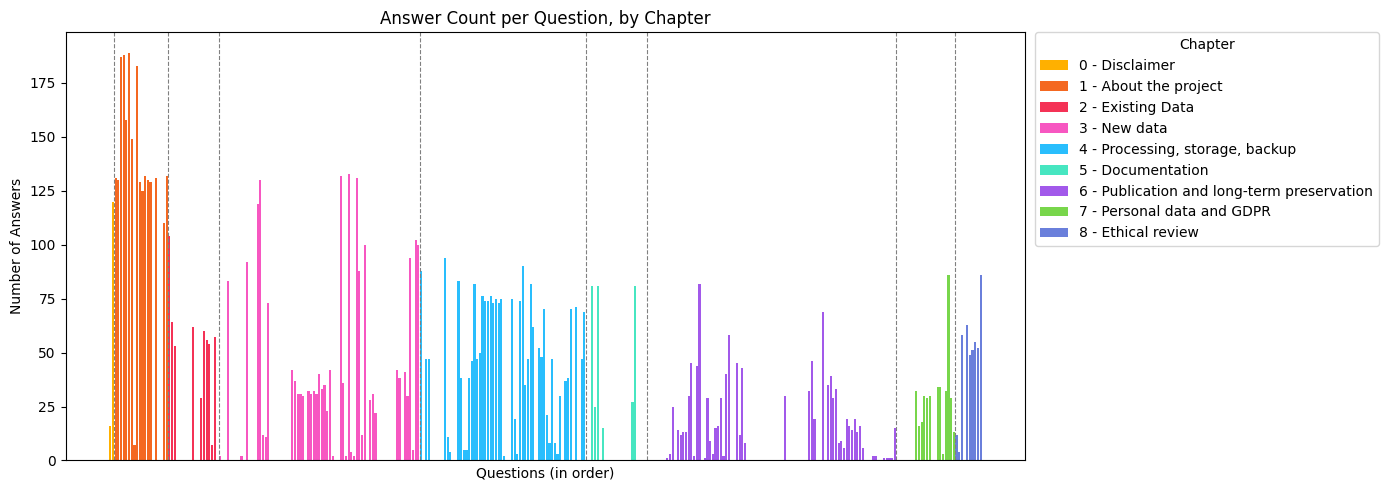

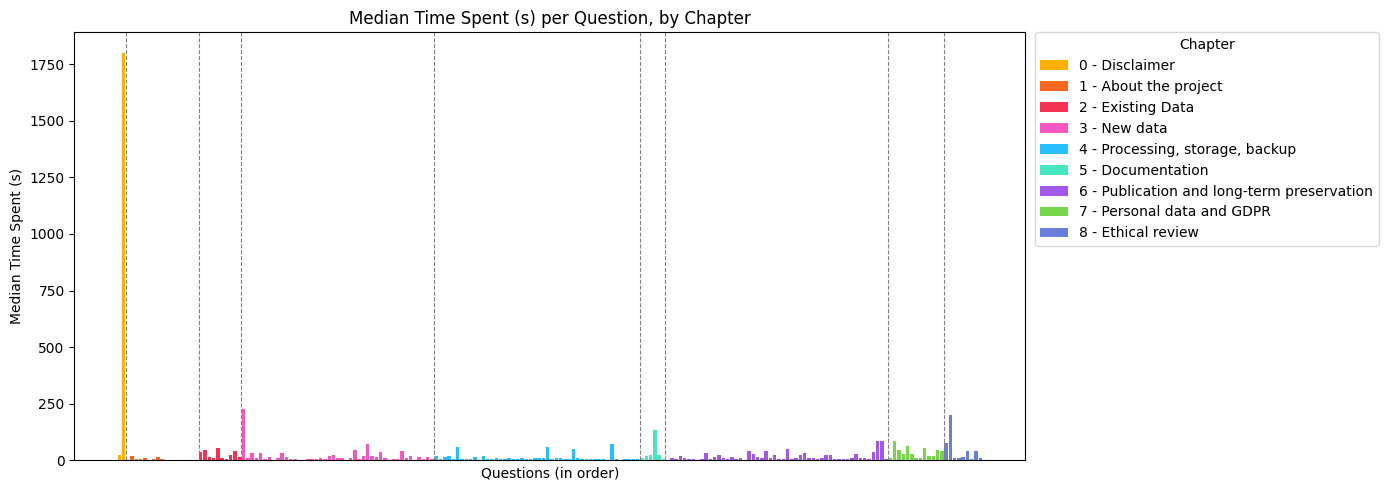

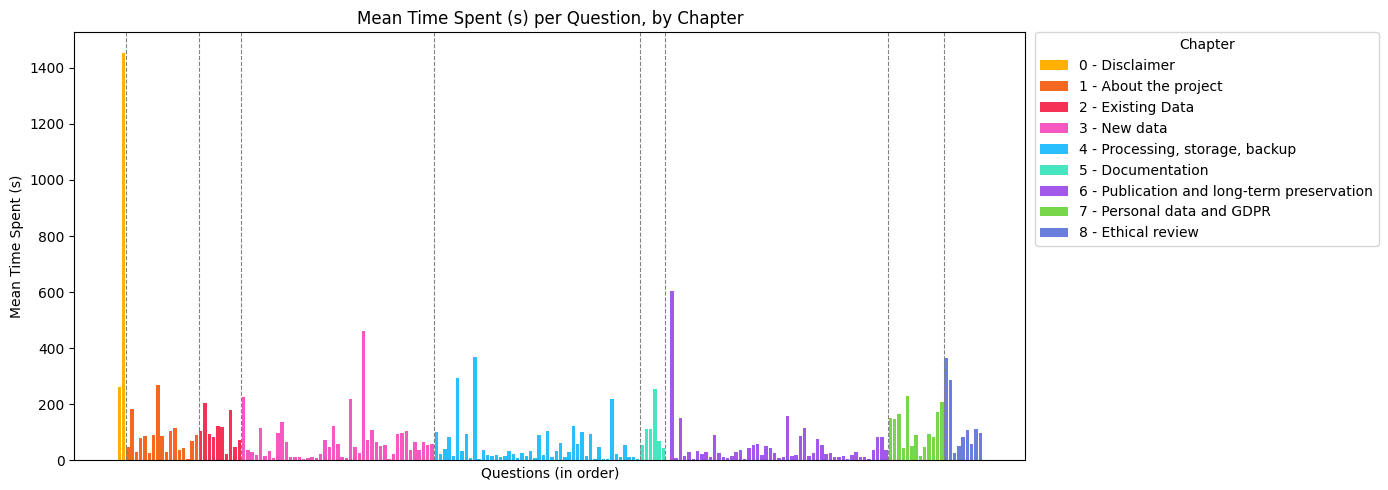

124 questions with zero answers:

                                        chapter                                                                                                                                     title                 type  depth                                                                                                                          km_ids
0                         1 - About the project                                                                                                                           Project acronym        ValueQuestion      1  [chalmers:root:3.0.1, chalmers:root:3.0.0, chalmers:root:3.0.2, chalmers:root:3.0.3, chalmers:root:3.0.5, chalmers:root:3.0.4]
1                         1 - About the project                                                                                         What specific hard/software do you need, and why?        ValueQuestion      1  [chalmers:root:3.0.1, chalmers:root:3.0.0, chalmers:root:3.0.2, cha

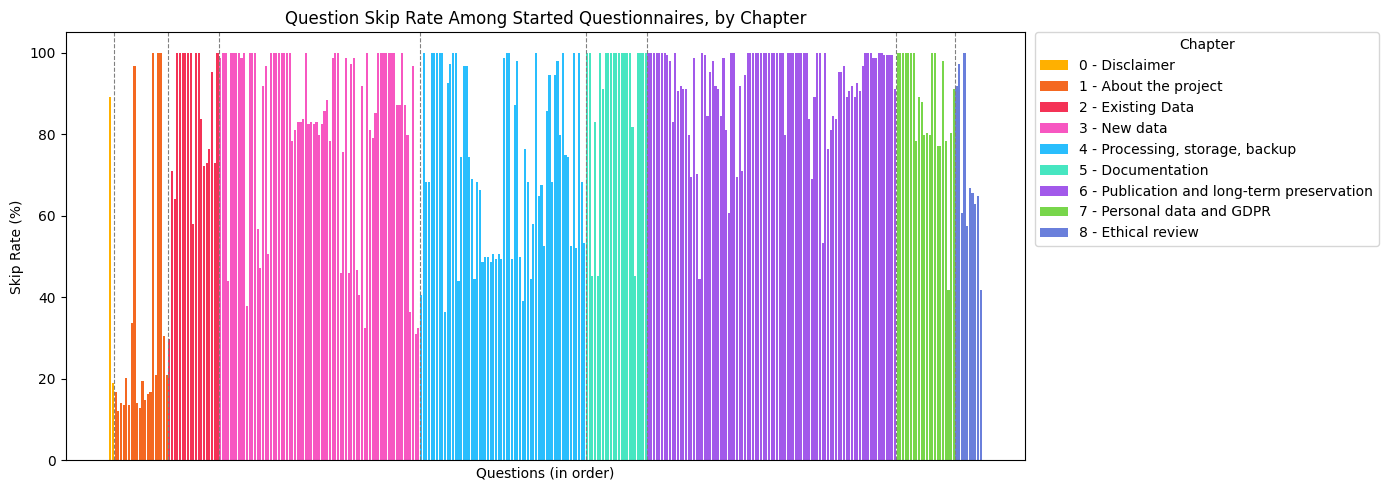

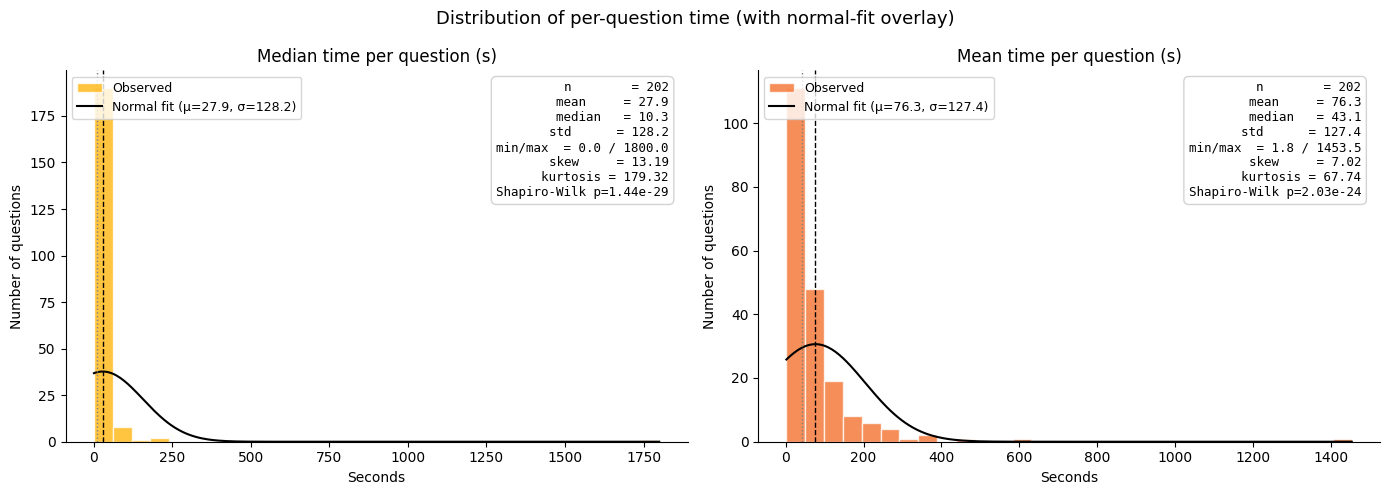


=== Outliers > 2 σ ===

[mean_time_s | from mean]  (5 questions)
 z_score  value_s  reference_val                                    chapter                                                                                                         title
   10.81   1453.5           76.3                             0 - Disclaimer Do you allow other (Chalmers approved) services to read some of the information in this data management plan?
    4.15    605.3           76.3 6 - Publication and long-term preservation                                                       Who will take care of authorization of potential users?
    3.02    461.5           76.3                               3 - New data                                                                      Why are you using a non-standard format?
    2.30    369.0           76.3            4 - Processing, storage, backup                                                                      How will you handle changes in the data?
    

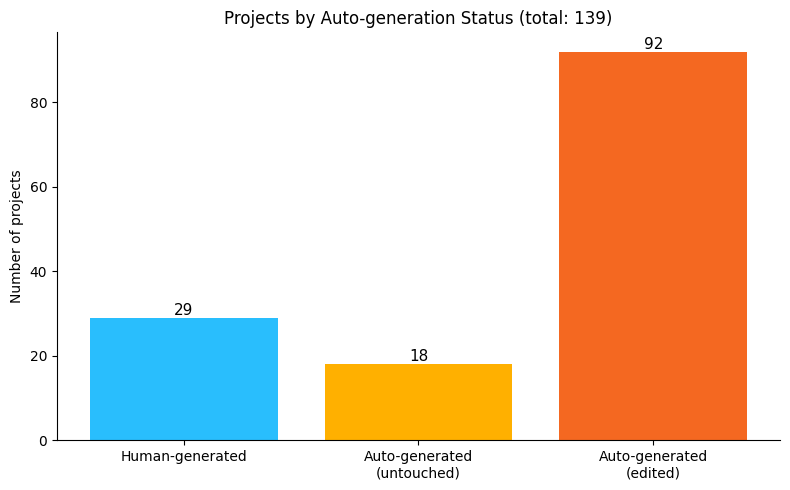

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sps

# ── Constants ────────────────────────────────────────────────────────────────

CHAPTER_LABELS = {
    'ca48f269-5a4e-42fb-a4e8-6f2dc9458e65': '0 - Disclaimer',
    '1e85da40-bbfc-4180-903e-6c569ed2da38': '1 - About the project',
    '82fd0cce-2b41-423f-92ad-636d0872045c': '2 - Existing Data',
    'b1df3c74-0b1f-4574-81c4-4cc2d780c1af': '3 - New data',
    '10a10ffd-bfe1-4c6b-bbb6-3dfb1e63a5d5': '4 - Processing, storage, backup',
    'c7194506-2a18-4436-8590-9bf584833172': '5 - Documentation',
    'd5b27482-b598-4b8c-b534-417d4ad27394': '6 - Publication and long-term preservation',
    '8eb418fe-f415-44cd-8027-5fac5fc025c1': '7 - Personal data and GDPR',
    '6fd759d2-917f-4489-bacd-2700a305cbed': '8 - Ethical review',
    '5897e561-05ce-4a38-a71b-12e4e96ebaec': '9 - Support',
}

CHAPTER_COLORS = [
    '#FFB000', '#F46821', '#F43256', '#F757C1', '#29BEFD',
    '#47E6C1', '#A259EA', '#78D64B', '#6A7FDB', '#777777',
]

AUTO_QUESTION_UUIDS = {
    '73d686bd-7939-412e-8631-502ee6d9ea7b', '6155ad47-3d1e-4488-9f2a-742de1e56580',
    '3a2ffc13-6a0e-4976-bb34-14ab6d938348', '6295a55d-48d7-4f3c-961a-45b38eeea41f',
    '68530470-1f1c-4448-8593-63a288713a66', '829dcda6-db8a-40ac-819a-92b9b52490f5',
    'c3dabaaf-c946-4a0d-889c-ede966f97667', 'f0ef08fd-d733-465c-bc66-5de0b826c41b',
    '22583d74-3c98-4e0a-b363-26d767c88212', 'de84b9b5-bcd0-4954-8370-72ea83916b8c',
    'cabc6f07-6015-454e-b97a-c34db4ec0c60', '36a87eac-402d-43fb-a0df-ac5963bdf87d',
    '0b12fb8c-ee0f-40c0-9c53-b6826b786a0c', '54ff3b18-652f-4235-8f9f-3c87e2d63169',
    '1ccbd0bb-4263-4240-9dc5-936ef09eef53',
}

AUTO_SIGNATURES = {
    '68530470-1f1c-4448-8593-63a288713a66': 'd8efc3fb-9717-4566-9529-e89e71b1554d',  # aff = CTH
    '829dcda6-db8a-40ac-819a-92b9b52490f5': 'f7468e79-c621-4ac9-95e0-263ebdf23c73',  # role = Contact
}

# ── I/O ──────────────────────────────────────────────────────────────────────

def load_pickles(date):
    return tuple(pd.read_pickle(f'{name}_{date}') for name in ('answers_df', 'projects_df', 'km_df'))

def clean_projects(df):
    return df[~df['name'].str.contains('test|draft', case=False, na=False)].reset_index(drop=True)

# ── Analysis: per-question stats ─────────────────────────────────────────────

def build_analysis_df(km_df, answers_df):
    km_df = km_df.copy()
    km_df['chapter'] = km_df['path'].str.split('.').str[0].map(CHAPTER_LABELS)

    unique_q = (
        km_df.sort_values('path')
        .drop_duplicates(subset='question_uuid')
        [['question_uuid', 'path', 'title', 'type', 'chapter']]
    )
    unique_q['depth'] = (unique_q['path'].str.count(r'\.') - 1).clip(lower=0) // 2

    km_presence   = km_df.groupby('question_uuid')['km_id'].agg(list).reset_index(name='km_ids')
    answer_counts = answers_df.groupby('question_uuid').size().reset_index(name='answer_count')

    return (
        unique_q
        .merge(km_presence,   on='question_uuid', how='left')
        .merge(answer_counts, on='question_uuid', how='left')
        .assign(answer_count=lambda df: df['answer_count'].fillna(0).astype(int))
        .sort_values('chapter')
        .reset_index(drop=True)
    )


def compute_time_per_question(answers_df):
    """
    Estimate time spent per question (seconds) using the gap between
    consecutive reply_timestamps within the same questionnaire.
    Returns both median and mean per question.
    Gaps > 30 min are capped to exclude session breaks.
    """
    df = answers_df.copy()
    df['reply_timestamp'] = pd.to_datetime(df['reply_timestamp'])
    df = df.sort_values(['questionnaire_uuid', 'reply_timestamp'])

    df['time_diff_s'] = (
        df.groupby('questionnaire_uuid')['reply_timestamp']
        .diff()
        .dt.total_seconds()
        .clip(upper=1800)
    )
    return (
        df.groupby('question_uuid')['time_diff_s']
        .agg(median_time_s='median', mean_time_s='mean')
        .reset_index()
    )


def compute_skip_rate(analysis_df, answers_df):
    n_started = answers_df['questionnaire_uuid'].nunique()
    answered_per_q = (
        answers_df.groupby('question_uuid')['questionnaire_uuid']
        .nunique()
        .reset_index(name='n_answered')
    )
    df = analysis_df.merge(answered_per_q, on='question_uuid', how='left')
    df['n_answered'] = df['n_answered'].fillna(0).astype(int)
    df['skip_rate']  = (1 - df['n_answered'] / n_started) * 100
    return df

# ── Analysis: per-project classification ─────────────────────────────────────

def classify_projects(answers_df, projects_df, project_id_col='uuid'):
    sig_sets = [
        set(answers_df.loc[
            (answers_df['question_uuid'] == q) & (answers_df['reply_value'] == v),
            'questionnaire_uuid'
        ].unique())
        for q, v in AUTO_SIGNATURES.items()
    ]
    auto_qids = set.intersection(*sig_sets) if sig_sets else set()
    answered_per_q = answers_df.groupby('questionnaire_uuid')['question_uuid'].agg(set)

    rows = []
    for qid in projects_df[project_id_col].unique():
        if qid in auto_qids:
            answered = answered_per_q.loc[qid]
            category = 'auto_edited' if (answered - AUTO_QUESTION_UUIDS) else 'auto_untouched'
        else:
            category = 'non_auto'
        rows.append((qid, category))

    return pd.DataFrame(rows, columns=['questionnaire_uuid', 'category'])

# ── Shared plot helper ───────────────────────────────────────────────────────

def _chapter_bar_plot(df, y_col, ylabel, title, filename):
    chapters  = sorted(df['chapter'].dropna().unique())
    color_map = {ch: CHAPTER_COLORS[i % len(CHAPTER_COLORS)] for i, ch in enumerate(chapters)}

    fig, ax = plt.subplots(figsize=(14, 5))
    for chapter in chapters:
        sub = df[df['chapter'] == chapter]
        ax.bar(sub.index, sub[y_col], color=color_map[chapter], label=chapter)

    for x in df.groupby('chapter', sort=False).apply(lambda g: g.index[-1], include_groups=False).values[:-1]:
        ax.axvline(x=x + 0.5, color='grey', linewidth=0.8, linestyle='--')

    ax.set_title(title)
    ax.set_xlabel('Questions (in order)')
    ax.set_ylabel(ylabel)
    ax.set_xticks([])
    ax.legend(title='Chapter', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

# ── Plots ────────────────────────────────────────────────────────────────────

def plot_answer_counts(df):
    _chapter_bar_plot(df, 'answer_count', 'Number of Answers',
                      'Answer Count per Question, by Chapter',
                      'answer_count_by_chapter.png')


def plot_time_per_question(analysis_df, answers_df, agg='median'):
    """y = median_time_s or mean_time_s per question, with chapters."""
    col   = f'{agg}_time_s'
    label = f'{agg.capitalize()} Time Spent (s)'
    time_df = compute_time_per_question(answers_df)
    df = (
        analysis_df
        .merge(time_df, on='question_uuid', how='left')
        .dropna(subset=[col])
        .reset_index(drop=True)
    )
    _chapter_bar_plot(df, col, label,
                      f'{label} per Question, by Chapter',
                      f'{agg}_time_per_question.png')


def list_zero_answer_questions(analysis_df):
    zero = (
        analysis_df[analysis_df['answer_count'] == 0]
        [['chapter', 'title', 'type', 'depth', 'km_ids']]
        .reset_index(drop=True)
    )
    print(f"{len(zero)} questions with zero answers:\n")
    print(zero.to_string())
    return zero


def plot_skip_rate(analysis_df, answers_df):
    df = compute_skip_rate(analysis_df, answers_df).reset_index(drop=True)
    _chapter_bar_plot(df, 'skip_rate', 'Skip Rate (%)',
                      'Question Skip Rate Among Started Questionnaires, by Chapter',
                      'skip_rate_by_chapter.png')


def plot_project_categories(classification_df):
    order  = ['non_auto', 'auto_untouched', 'auto_edited']
    counts = classification_df['category'].value_counts().reindex(order, fill_value=0)
    labels = ['Human-generated', 'Auto-generated\n(untouched)', 'Auto-generated\n(edited)']
    colors = ['#29BEFD', '#FFB000', '#F46821']

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, counts.values, color=colors)
    for bar, n in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{n}', ha='center', va='bottom', fontsize=11)

    ax.set_title(f'Projects by Auto-generation Status (total: {counts.sum()})')
    ax.set_ylabel('Number of projects')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('project_categories.png', dpi=150)
    plt.show()


def plot_time_distributions(answers_df, bins=30):
    """
    Distribution of per-question median and mean times, with normal-curve
    overlay scaled to counts, key descriptive stats, and Shapiro-Wilk test.
    """
    time_df = compute_time_per_question(answers_df).dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    series_specs = [
        ('median_time_s', 'Median time per question (s)', '#FFB000', axes[0]),
        ('mean_time_s',   'Mean time per question (s)',   '#F46821', axes[1]),
    ]

    for col, label, color, ax in series_specs:
        data = time_df[col].dropna().values

        # Histogram (raw counts)
        counts, bin_edges, _ = ax.hist(
            data, bins=bins, color=color, alpha=0.75,
            edgecolor='white', label='Observed'
        )
        bin_width = bin_edges[1] - bin_edges[0]

        # Normal-curve overlay scaled to counts (pdf * n * bin_width)
        mu, sigma = np.mean(data), np.std(data, ddof=1)
        x = np.linspace(data.min(), data.max(), 300)
        ax.plot(
            x, sps.norm.pdf(x, mu, sigma) * len(data) * bin_width,
            color='black', linewidth=1.5,
            label=f'Normal fit (μ={mu:.1f}, σ={sigma:.1f})'
        )

        ax.axvline(mu, color='black', linestyle='--', linewidth=1)
        ax.axvline(np.median(data), color='grey', linestyle=':', linewidth=1)

        skew = sps.skew(data)
        kurt = sps.kurtosis(data)
        try:
            sw_stat, sw_p = sps.shapiro(data)
            sw_text = f'Shapiro-Wilk p={sw_p:.3g}'
        except Exception:
            sw_text = 'Shapiro-Wilk: n/a'

        stats_text = (
            f"n        = {len(data)}\n"
            f"mean     = {mu:.1f}\n"
            f"median   = {np.median(data):.1f}\n"
            f"std      = {sigma:.1f}\n"
            f"min/max  = {data.min():.1f} / {data.max():.1f}\n"
            f"skew     = {skew:.2f}\n"
            f"kurtosis = {kurt:.2f}\n"
            f"{sw_text}"
        )
        ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
                ha='right', va='top', family='monospace', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='lightgrey'))

        ax.set_title(label)
        ax.set_xlabel('Seconds')
        ax.set_ylabel('Number of questions')
        ax.legend(loc='upper left', fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle('Distribution of per-question time (with normal-fit overlay)', fontsize=13)
    plt.tight_layout()
    plt.savefig('time_distributions.png', dpi=150)
    plt.show()

def find_time_outliers(answers_df, analysis_df, n_std=2):
    """
    Identify questions whose median or mean time-per-question is more than
    n_std standard deviations away from the population mean and median.

    Returns a DataFrame flagging each outlier and why.
    """
    time_df = compute_time_per_question(answers_df).dropna()
    df = time_df.merge(
        analysis_df[['question_uuid', 'chapter', 'title', 'depth']],
        on='question_uuid', how='left'
    )

    rows = []
    for col in ['median_time_s', 'mean_time_s']:
        vals = df[col].values
        mu, med, sd = np.mean(vals), np.median(vals), np.std(vals, ddof=1)
        threshold = n_std * sd

        df[f'{col}_z_from_mean']   = (df[col] - mu)  / sd
        df[f'{col}_z_from_median'] = (df[col] - med) / sd

        outliers_mean   = df[np.abs(df[col] - mu)  > threshold].copy()
        outliers_median = df[np.abs(df[col] - med) > threshold].copy()

        for which, sub in [('mean', outliers_mean), ('median', outliers_median)]:
            for _, r in sub.iterrows():
                rows.append({
                    'metric':        col,
                    'reference':     which,
                    'value_s':       round(r[col], 1),
                    'reference_val': round(mu if which == 'mean' else med, 1),
                    'std':           round(sd, 1),
                    'z_score':       round((r[col] - (mu if which == 'mean' else med)) / sd, 2),
                    'chapter':       r['chapter'],
                    'title':         r['title'],
                    'question_uuid': r['question_uuid'],
                })

    out = (
        pd.DataFrame(rows)
        .sort_values(['metric', 'reference', 'z_score'], ascending=[True, True, False])
        .reset_index(drop=True)
    )

    print(f"\n=== Outliers > {n_std} σ ===")
    for (metric, ref), sub in out.groupby(['metric', 'reference']):
        print(f"\n[{metric} | from {ref}]  ({len(sub)} questions)")
        print(sub[['z_score', 'value_s', 'reference_val', 'chapter', 'title']].to_string(index=False))

    return out

# ── Main ─────────────────────────────────────────────────────────────────────

if __name__ == '__main__':
    answers_df, projects_df, km_df = load_pickles('2026-04-23')

    clean_projects_df = clean_projects(projects_df)
    analysis_df       = build_analysis_df(km_df, answers_df)

    # Per-question analyses
    plot_answer_counts(analysis_df)
    plot_time_per_question(analysis_df, answers_df, agg='median')
    plot_time_per_question(analysis_df, answers_df, agg='mean')
    zero_df = list_zero_answer_questions(analysis_df)
    plot_skip_rate(analysis_df, answers_df)

    # Distribution analysis with descriptive stats
    plot_time_distributions(answers_df)

    # Give info on which questions have a median or mean answer time more than 2standard deviations off
    outliers = find_time_outliers(answers_df, analysis_df, n_std=2)

    # Per-project classification
    classification_df = classify_projects(answers_df, clean_projects_df)
    print(classification_df['category'].value_counts())
    plot_project_categories(classification_df)